In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

utilization_data = {}

base_path = "../../Data/Medicare_Part_B_NSD"

valid_HCPCS = [
    31231, 31233, 31235, 31237, 31238, 31239, 31240,
    31254, 31255, 31256, 31267, 31276, 31287, 31288,
    31290, 31291, 31292, 31293, 31294
]
valid_HCPCS_str = [str(code) for code in valid_HCPCS]

for year in range(2000,2025):
    file_path = f"{base_path}/{year}.csv"
    df = pd.read_csv(file_path)

    df["HCPCS"] = df["HCPCS"].replace("", pd.NA).ffill()
    totals = df[df["MODIFIER"] == "TOTAL"].copy()
    totals["HCPCS"] = pd.to_numeric(totals["HCPCS"], errors="coerce")
    totals = totals.dropna(subset=["HCPCS"])
    totals["HCPCS"] = totals["HCPCS"].astype(int)
    totals["HCPCS"] = totals["HCPCS"].astype(str)
    totals = totals[totals["HCPCS"].isin(valid_HCPCS_str)]

    for col in ["ALLOWED CHARGES", "PAYMENT"]:
        totals[col] = totals[col].str.replace(r"[\$,]", "", regex=True).astype(float)

    totals["Year"] = year
    utilization_data[year] = totals

combined_df = pd.concat(utilization_data.values(), ignore_index=True)

combined_df = combined_df[["HCPCS", "ALLOWED SERVICES", "PAYMENT", "Year"]]

inflation_path = "../../Data/Inflation_Table/inflation_table.csv"
inflation_df = pd.read_csv(inflation_path)

combined_df = combined_df.merge(inflation_df, on="Year", how="left")

combined_df["Medicare Reimbursement (in Millions)"] = pd.to_numeric(combined_df["PAYMENT"], errors="coerce")

combined_df["Medicare Reimbursement (Inflation Adjusted, in Millions)"] = (
    combined_df["Medicare Reimbursement (in Millions)"] * combined_df["Inflation Factor"] / 1.03
)

combined_df["ALLOWED SERVICES"] = (
    combined_df["ALLOWED SERVICES"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [16]:
grouping_path = "../../Supplementary_Tables/ST1/ST1.csv"
grouping_df = pd.read_csv(grouping_path)

combined_df["HCPCS"] = combined_df["HCPCS"].astype(str)
grouping_df["CPT Code"] = grouping_df["CPT Code"].astype(str)

combined_df = combined_df.merge(
    grouping_df[["CPT Code", "Group Name", "Group Number"]],
    left_on="HCPCS",
    right_on="CPT Code",
    how="left"
)

combined_df = combined_df.drop(columns=["CPT Code"])

grouped_df = (
    combined_df
    .groupby(["Year", "Group Name"], as_index=False)
    .sum(numeric_only=True)
)[["Year", "Group Name", "ALLOWED SERVICES", "Medicare Reimbursement (in Millions)", "Medicare Reimbursement (Inflation Adjusted, in Millions)"]]



num_services = grouped_df.pivot(
    index="Group Name",
    columns="Year",
    values="ALLOWED SERVICES"
).sort_index(axis=1)

reimbursement = grouped_df.pivot(
    index="Group Name",
    columns="Year",
    values="Medicare Reimbursement (in Millions)"
).sort_index(axis=1)

inflation_reimbursement = grouped_df.pivot(
    index="Group Name",
    columns="Year",
    values="Medicare Reimbursement (Inflation Adjusted, in Millions)"
).sort_index(axis=1)

reimbursement_per_service = reimbursement/num_services
inflation_reimbursement_per_service = inflation_reimbursement/num_services

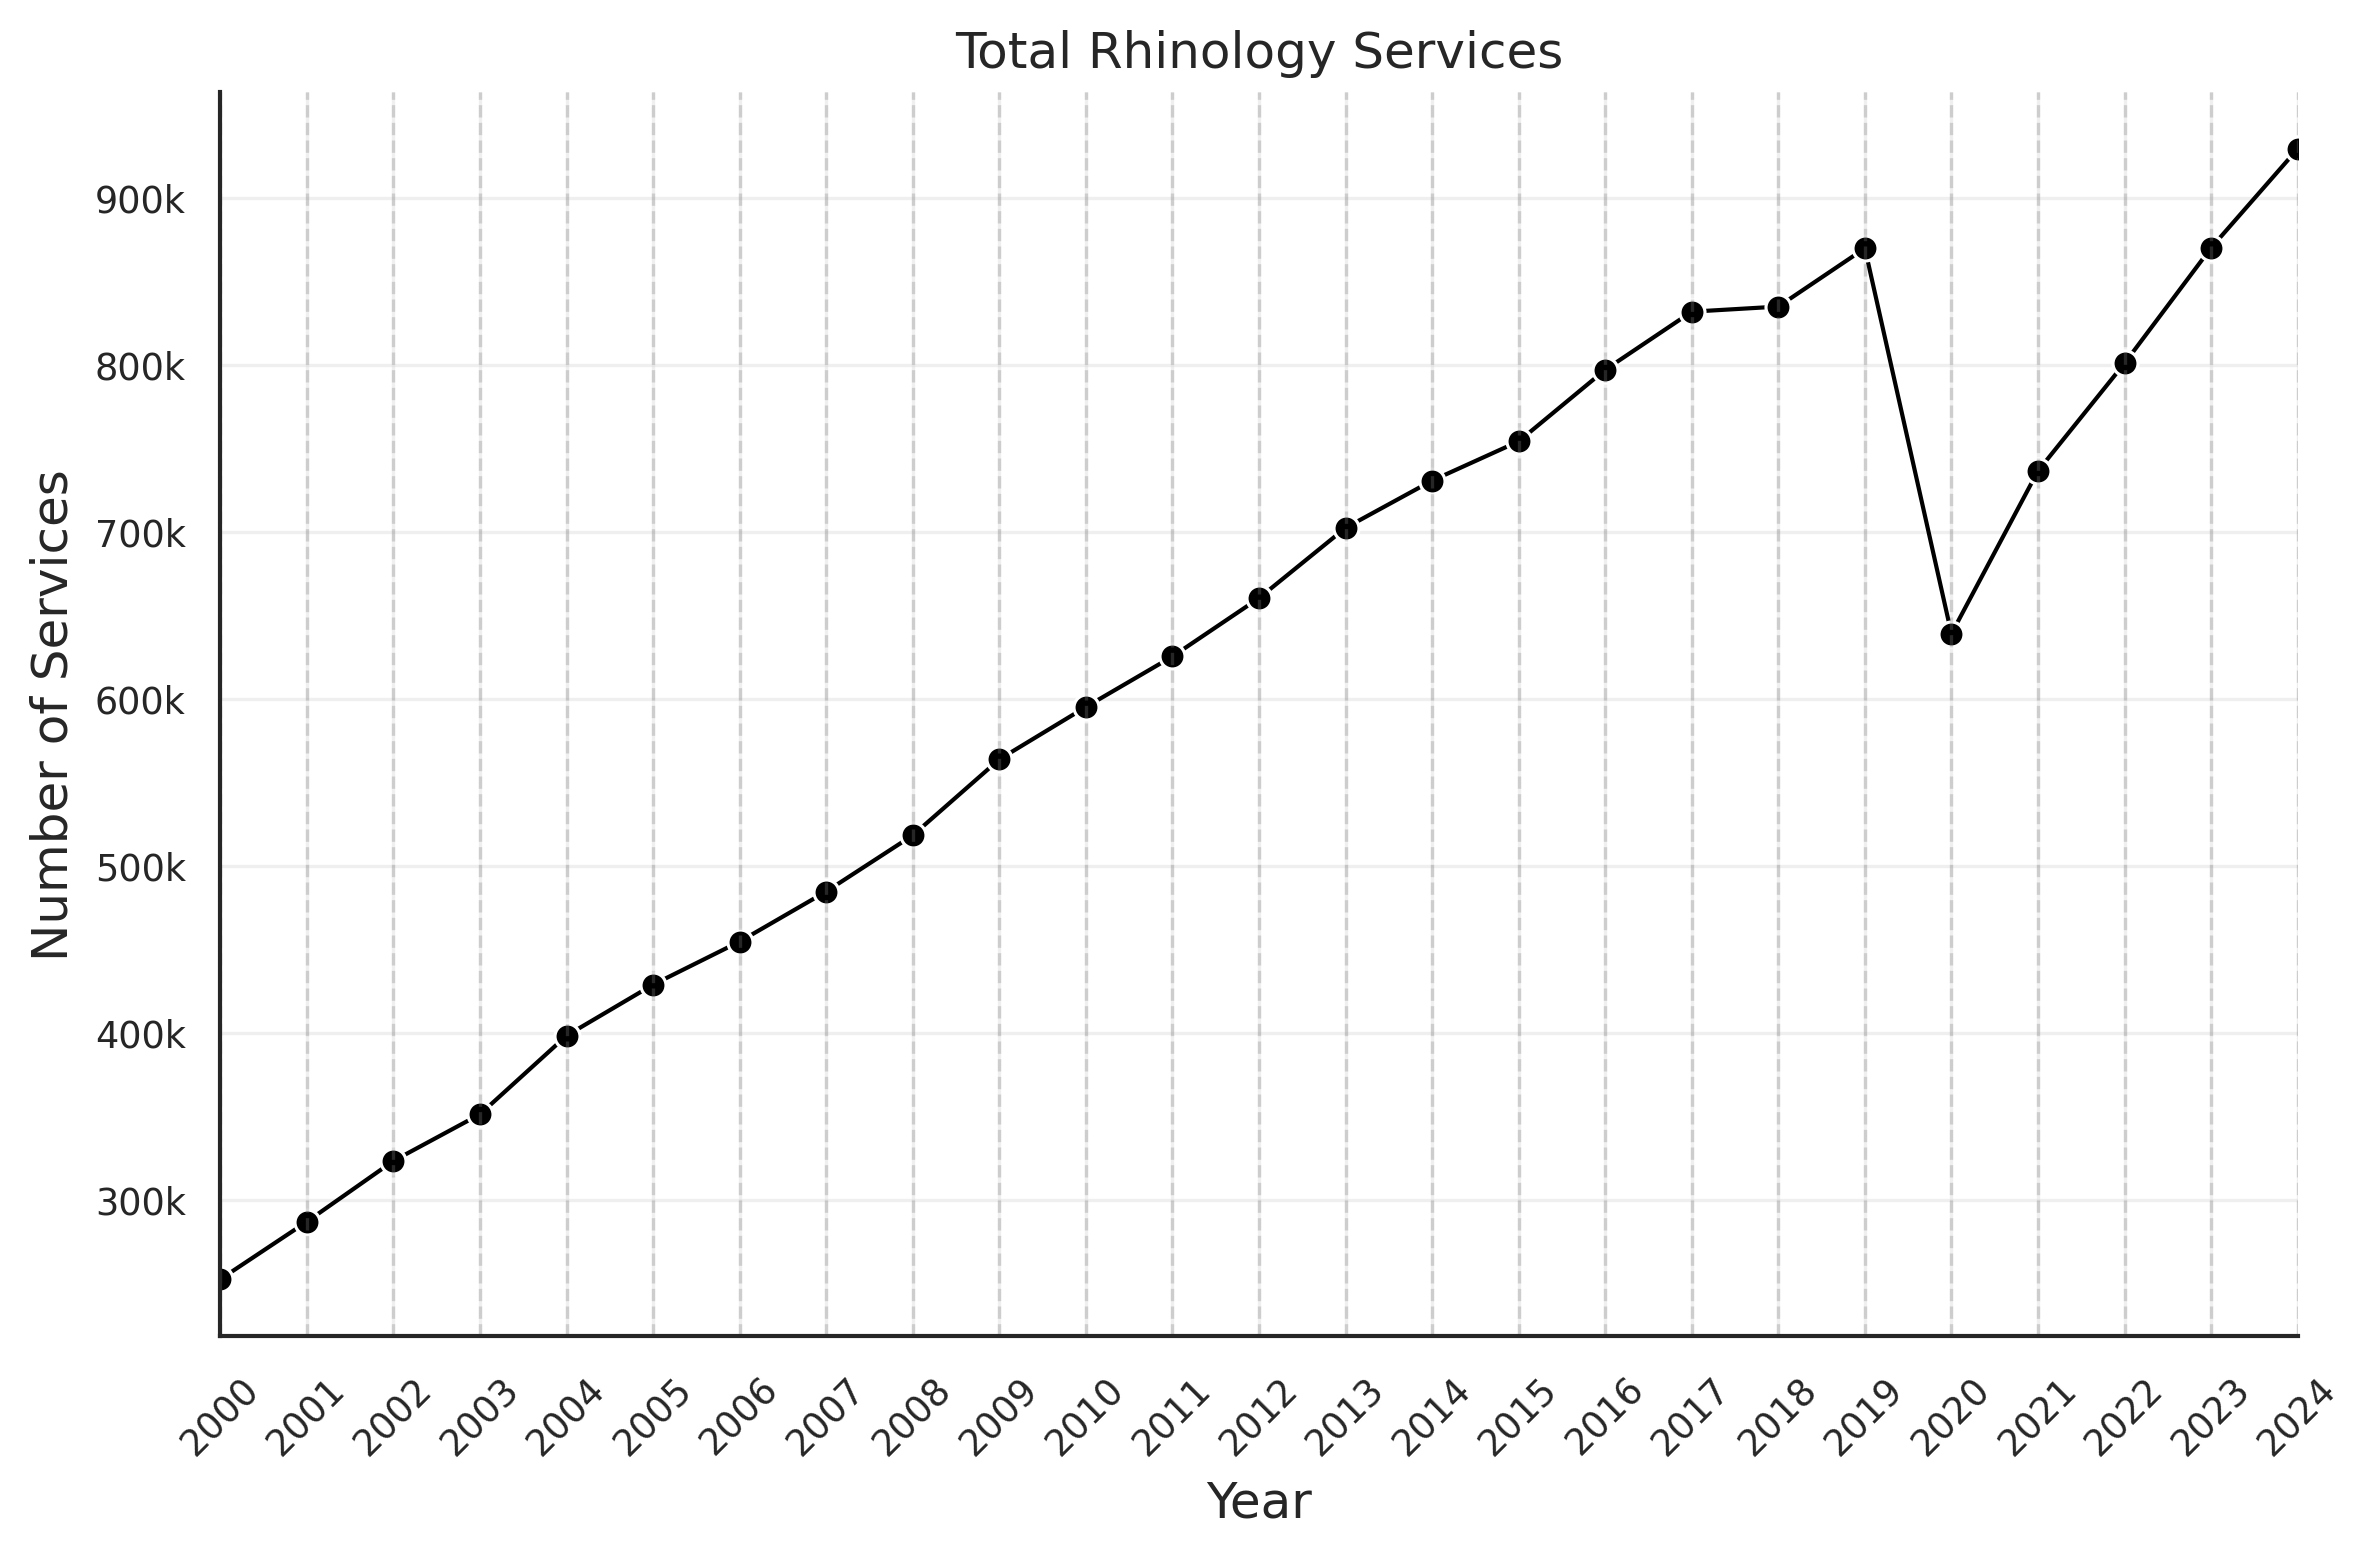

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

services_per_year = num_services.sum(axis=0)
df_plot = services_per_year.reset_index()
df_plot.columns = ['Year', 'Number of Services']
df_plot["Year"] = df_plot["Year"].astype(int)

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

sns.lineplot(
    data=df_plot,
    x="Year",
    y="Number of Services",
    marker='o',
    markersize=6,
    linewidth=1,
    color='black',
    ax=ax
)

plt.title("Total Rhinology Services", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Services", fontsize=12)

ax.set_xlim(2000, 2024)
ax.set_xticks(range(2000, 2025))
plt.xticks(rotation=45)

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000:g}k'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(alpha=0.3)
for year in range(2000, 2026):
    plt.axvline(x=year, linestyle="--", color="gray", alpha=0.3, linewidth=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('F3.pdf')

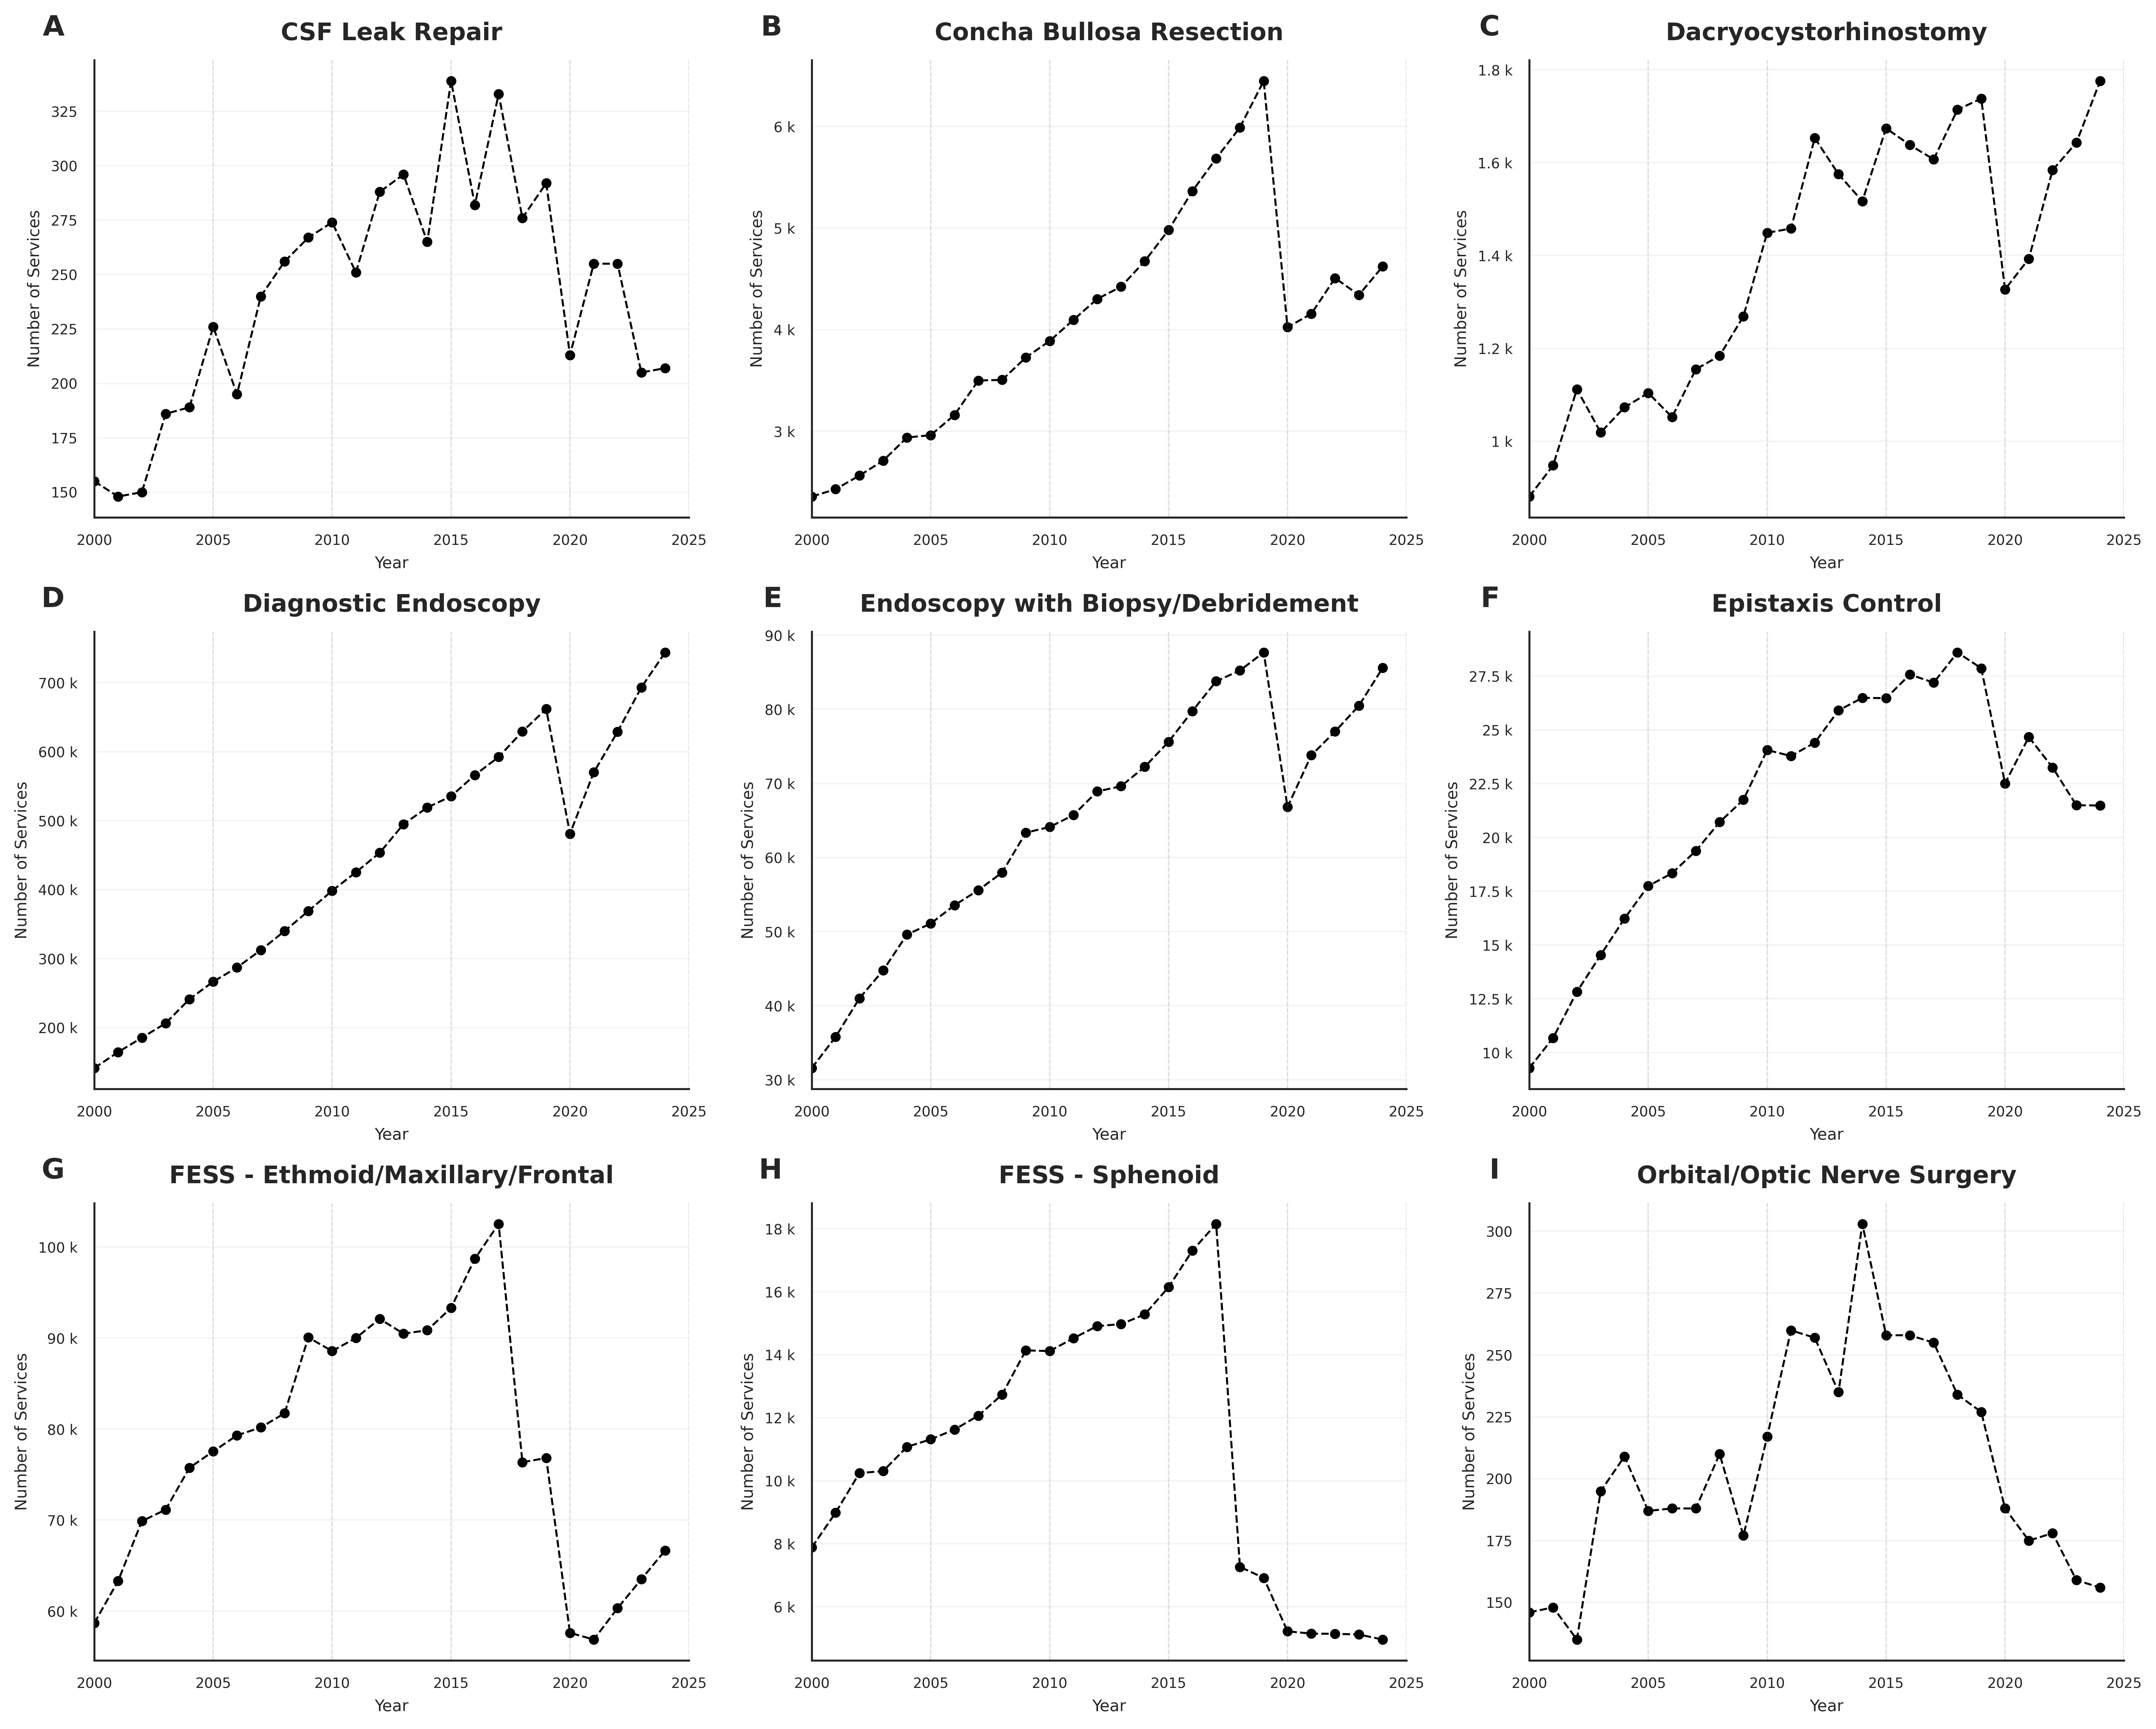

In [20]:
import string
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import math
from scipy import stats

alphabet = string.ascii_uppercase
df = num_services
years = np.array([int(c) for c in df.columns])
groups = df.index.tolist()
num_groups = len(groups)
grid_size = 9
num_pages = math.ceil(num_groups / grid_size)

for p in range(num_pages):
    fig, axes = plt.subplots(3, 3, figsize=(15, 12), dpi=500)
    axes = axes.flatten()
    
    for i in range(grid_size):
        idx = p * grid_size + i
        ax = axes[i]
        
        if idx < num_groups:
            name = groups[idx]
            values = df.loc[name].values
            
            ax.text(-0.05, 1.1, alphabet[i], transform=ax.transAxes, 
                    fontsize=14, fontweight='bold', va='top', ha='right')

            ax.plot(years, values, marker='o', markersize=4, 
                    linewidth=1, color='black', linestyle='--')
            
            ax.set_title(name, fontsize=12, pad=10, fontweight='bold')
            ax.set_ylabel('Number of Services', fontsize=8)
            ax.set_xlabel('Year', fontsize=8)
            
            ax.set_xlim(2000, 2025)
            ax.set_xticks([2000, 2005, 2010, 2015, 2020, 2025])
            ax.tick_params(axis='both', labelsize=7)
            
            ax.yaxis.set_major_formatter(mtick.EngFormatter())
            
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            ax.grid(alpha=0.2)
            for year in range(2000, 2026, 5):
                ax.axvline(x=year, linestyle="--", color="gray", alpha=0.2, linewidth=0.6)
        else:
            ax.axis('off')
            
    plt.tight_layout()
    plt.savefig(f'../../Supplementary_Figures/SF1/SF1.pdf')
    plt.show()
    plt.close()